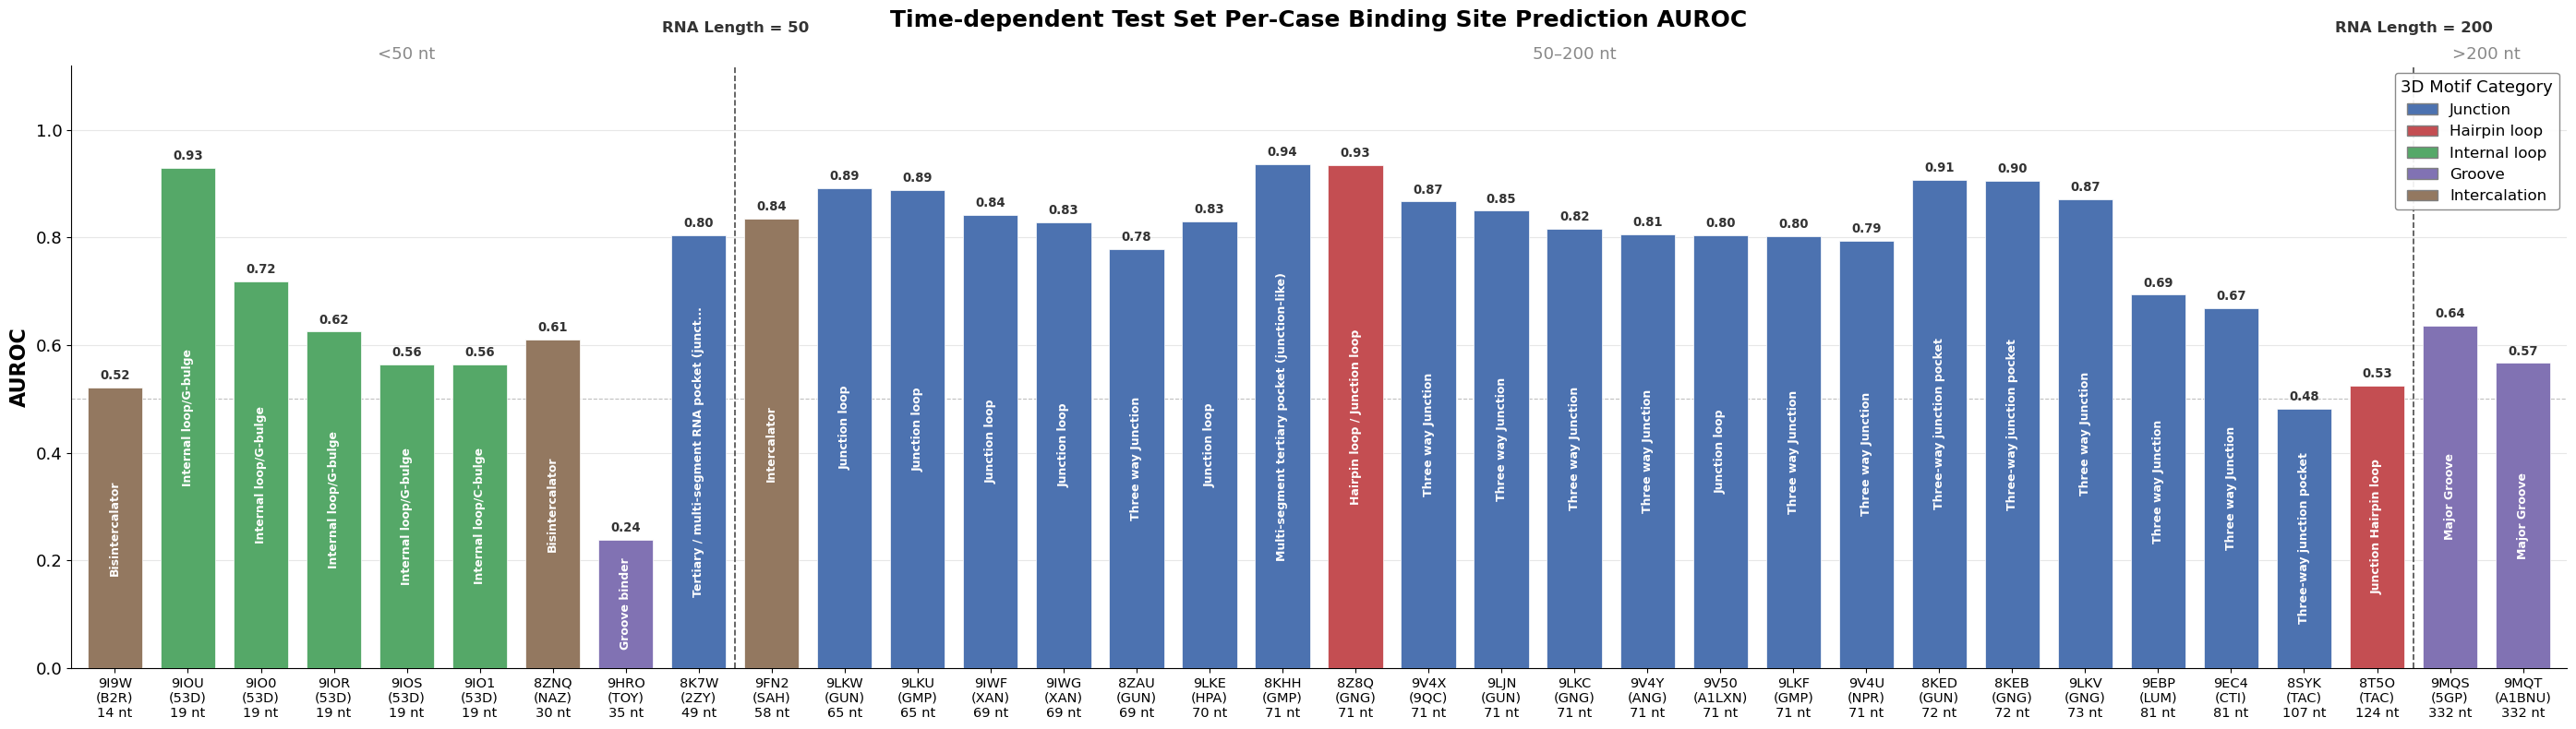

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data ──
data = {
    "RNA_Length": [72,49,71,72,107,124,69,71,19,19,19,19,19,332,332,58,
                   65,65,71,71,71,71,71,71,71,35,69,14,30,70,69,81,81,73],
    "Motif": [
        "Three-way junction pocket",
        "Tertiary / multi-segment RNA pocket (junction-like)",
        "Multi-segment tertiary pocket (junction-like)",
        "Three-way junction pocket",
        "Three-way junction pocket",
        "Junction Hairpin loop",
        "Three way Junction",
        "Hairpin loop / Junction loop",
        "Internal loop/G-bulge","Internal loop/G-bulge","Internal loop/G-bulge",
        "Internal loop/G-bulge","Internal loop/C-bulge",
        "Major Groove","Major Groove",
        "Intercalator",
        "Junction loop","Junction loop",
        "Three way Junction","Three way Junction","Three way Junction",
        "Three way Junction","Three way Junction","Three way Junction",
        "Junction loop",
        "Groove binder",
        "Junction loop",
        "Bisintercalator","Bisintercalator",
        "Junction loop",
        "Junction loop",
        "Three way Junction","Three way Junction",
        "Three way Junction",
    ],
    "Ligand": ["GUN","2ZY","GMP","GNG","TAC","TAC","GUN","GNG",
               "53D","53D","53D","53D","53D",
               "A1BNU","5GP","SAH",
               "GMP","GUN",
               "GNG","GMP","9QC","ANG","NPR","GUN","A1LXN",
               "TOY","XAN","B2R","NAZ","HPA","XAN",
               "CTI","LUM","GNG"],
    "PDB_ID": ["8KED","8K7W","8KHH","8KEB","8SYK","8T5O","8ZAU","8Z8Q",
               "9IOU","9IOS","9IO0","9IOR","9IO1",
               "9MQT","9MQS","9FN2",
               "9LKU","9LKW",
               "9LKC","9LKF","9V4X","9V4Y","9V4U","9LJN","9V50",
               "9HRO","9IWF","9I9W","8ZNQ","9LKE","9IWG",
               "9EC4","9EBP","9LKV"],
    "AUROC": [0.9071,0.8043,0.9357,0.9047,0.482,0.5252,0.7783,0.9338,
              0.9295,0.5643,0.7179,0.625,0.5641,
              0.5666,0.6364,0.8353,
              0.8878,0.8922,
              0.8154,0.8028,0.8667,0.8062,0.7945,0.8495,0.8039,
              0.2386,0.8422,0.5208,0.61,0.83,0.828,
              0.6687,0.6936,0.8708],
}

df = pd.DataFrame(data)

# ── Motif mapping (case-insensitive lookup) ──
motif_mapping = {
    "Three-way junction pocket": "Junction",
    "Tertiary / multi-segment RNA pocket (junction-like)": "Junction",
    "Multi-segment tertiary pocket (junction-like)": "Junction",
    "junction Hairpin loop": "Hairpin loop",
    "three way Junction": "Junction",
    "Hairpin loop / Junction loop": "Hairpin loop",
    "Internal loop/G-bulge": "Internal loop",
    "Internal loop/C-bulge": "Internal loop",
    "Major Groove": "Groove",
    "Intercalator": "Intercalation",
    "Junction loop": "Junction",
    "groove binder": "Groove",
    "bisintercalator": "Intercalation",
}

# Build case-insensitive lookup
_motif_lower = {k.lower(): v for k, v in motif_mapping.items()}

def map_motif(m):
    return _motif_lower.get(m.lower(), m)

df["Motif_Group"] = df["Motif"].apply(map_motif)

# ── Sort by RNA length ascending, then by AUROC descending within same length ──
df = df.sort_values(["RNA_Length", "AUROC"], ascending=[True, False]).reset_index(drop=True)

# ── Colour palette ──
group_order = ["Junction", "Hairpin loop", "Internal loop", "Groove", "Intercalation"]
palette = {
    "Junction":      "#4C72B0",
    "Hairpin loop":  "#C44E52",
    "Internal loop": "#55A868",
    "Groove":        "#8172B3",
    "Intercalation": "#937860",
}

# ── Build x-labels: PDB_ID (Ligand)\nRNA_Length nt ──
df["Label"] = df["PDB_ID"] + "\n(" + df["Ligand"] + ")\n" + df["RNA_Length"].astype(str) + " nt"

# ── Plot ──
fig, ax = plt.subplots(figsize=(28, 8))

for i, row in df.iterrows():
    color = palette[row["Motif_Group"]]
    ax.bar(i, row["AUROC"], color=color, width=0.75,
           edgecolor="white", linewidth=0.5, zorder=3)

    # Write detailed motif annotation inside the bar (vertical text)
    motif_text = row["Motif"]
    if len(motif_text) > 45:
        motif_text = motif_text[:42] + "..."
    text_y = row["AUROC"] / 2
    ax.text(i, text_y, motif_text,
            ha="center", va="center", fontsize=9, color="white",
            fontweight="bold", rotation=90, zorder=4,
            clip_on=True)

    # Annotate AUROC value on top of each bar
    ax.text(i, row["AUROC"] + 0.01, f'{row["AUROC"]:.2f}',
            ha="center", va="bottom", fontsize=9.5, fontweight="bold", color="#333333")

# ── Vertical dashed lines to separate length regions ──
boundary_50 = None
boundary_200 = None
for i, row in df.iterrows():
    if boundary_50 is None and row["RNA_Length"] >= 50:
        boundary_50 = i - 0.5
    if boundary_200 is None and row["RNA_Length"] > 200:
        boundary_200 = i - 0.5

if boundary_50 is not None:
    ax.axvline(x=boundary_50, color="black", linestyle="--", linewidth=1.2, alpha=0.7, zorder=2)
    ax.text(boundary_50, 1.05, "RNA Length = 50", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="#333", transform=ax.get_xaxis_transform())
if boundary_200 is not None:
    ax.axvline(x=boundary_200, color="black", linestyle="--", linewidth=1.2, alpha=0.7, zorder=2)
    ax.text(boundary_200, 1.05, "RNA Length = 200", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="#333", transform=ax.get_xaxis_transform())

# Region labels
if boundary_50 is not None and boundary_200 is not None:
    ax.text(((-0.5) + boundary_50) / 2, 1.01, "<50 nt", ha="center", fontsize=13,
            color="#888", transform=ax.get_xaxis_transform())
    ax.text((boundary_50 + boundary_200) / 2, 1.01, "50–200 nt", ha="center", fontsize=13,
            color="#888", transform=ax.get_xaxis_transform())
    ax.text((boundary_200 + len(df) - 0.5) / 2, 1.01, ">200 nt", ha="center", fontsize=13,
            color="#888", transform=ax.get_xaxis_transform())

# Reference line at 0.5
ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, zorder=1)

# Axes
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["Label"], rotation=0, ha="center", fontsize=10.5)
ax.set_ylabel("AUROC", fontsize=16, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.set_xlim(-0.6, len(df) - 0.4)
ax.tick_params(axis="y", labelsize=13)

# ── Legend: motif group (colour) only ──
present_groups = [g for g in group_order if g in df["Motif_Group"].values]
motif_handles = [mpatches.Patch(facecolor=palette[g], edgecolor="grey", label=g) for g in present_groups]
ax.legend(handles=motif_handles, title="3D Motif Category",
          loc="upper right", fontsize=12, title_fontsize=13,
          framealpha=0.92, edgecolor="grey")

ax.set_title("Time-dependent Test Set Per-Case Binding Site Prediction AUROC", fontsize=18, fontweight="bold", pad=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig("binding_site_by_case_auroc.png", dpi=600, bbox_inches="tight")
plt.show()